In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset Loading

In [187]:
t1_data = pd.read_excel("multi_omics/T1.xlsx")
t2_data = pd.read_excel("multi_omics/T2.xlsx")
adc_data = pd.read_excel("multi_omics/ADC.xlsx")

In [188]:
t1_data.head()

,case,center,Label,FrequencySize,MaxIntensity,MeanDeviation,MeanValue,MedianIntensity,MinIntensity,Percentile10,...,HighIntensityEmphasis,HighIntensityLargeAreaEmphasis,HighIntensitySmallAreaEmphasis,IntensityVariability,LargeAreaEmphasis,LowIntensityEmphasis,LowIntensityLargeAreaEmphasis,LowIntensitySmallAreaEmphasis,SmallAreaEmphasis,ZonePercentage
0,1,1,1,8589.0,1017.0,7.540000e-07,511.922,466.787,184.0,391.3020,...,299148.0,324056.0,292921.0,3.67700,1.11442,0.000004,0.000005,0.000004,0.971395,0.822549
1,2,1,1,2020.0,511.0,-1.380000e-06,297.105,298.416,113.0,194.1910,...,118916.0,130642.0,115984.0,2.69194,1.09953,0.000010,0.000011,0.000010,0.975118,0.861224
2,3,1,1,19170.0,204.0,-1.220000e-07,148.601,147.820,98.0,130.1610,...,23113.3,51108.6,19351.8,91.84190,2.22174,0.000045,0.000100,0.000038,0.835799,23.146900
3,4,1,1,170348.0,487.0,-4.760000e-05,308.911,305.326,108.0,265.9530,...,98481.4,161895.0,87852.1,179.64100,1.65189,0.000011,0.000018,0.000009,0.891355,44.953600
4,5,1,1,1949.0,247.0,3.630000e-07,121.593,116.264,60.0,85.5732,...,16556.4,27795.9,14805.7,15.79750,1.80000,0.000079,0.000149,0.000069,0.880402,6.324110


In [189]:
t2_data.head()

,case,center,Label,FrequencySize,MaxIntensity,MeanDeviation,MeanValue,MedianIntensity,MinIntensity,Percentile10,...,HighIntensityEmphasis,HighIntensityLargeAreaEmphasis,HighIntensitySmallAreaEmphasis,IntensityVariability,LargeAreaEmphasis,LowIntensityEmphasis,LowIntensityLargeAreaEmphasis,LowIntensitySmallAreaEmphasis,SmallAreaEmphasis,ZonePercentage
0,1,1,1,47213.0,828.0,-1.880000e-06,407.414,409.148,106.0,309.2100,...,200951.0,256356.0,188984.0,30.11730,1.26833,0.000006,0.000007,0.000006,0.942208,9.388890
1,2,1,1,4454.0,362.0,1.790000e-06,154.423,153.426,34.0,99.8949,...,25589.8,35339.1,23610.2,8.32258,1.36794,0.000049,0.000067,0.000046,0.924885,3.800770
2,3,1,1,2529.0,228.0,7.260000e-08,142.251,142.055,61.0,111.6800,...,20668.5,27722.4,19142.4,12.23850,1.33259,0.000054,0.000071,0.000051,0.927468,4.334950
3,4,1,1,40826.0,589.0,1.290000e-06,252.891,249.635,46.0,184.4840,...,65436.7,90967.7,60524.5,39.24360,1.39474,0.000018,0.000025,0.000017,0.923513,12.539200
4,5,1,1,1464.0,714.0,3.660000e-07,280.851,274.723,41.0,111.4830,...,68041.8,74884.5,66357.3,2.36495,1.18351,0.000039,0.000049,0.000036,0.956415,0.805648


In [190]:
adc_data.head()

,case,center,Label,FrequencySize,MaxIntensity,MeanDeviation,MeanValue,MedianIntensity,MinIntensity,Percentile10,...,HighIntensityEmphasis,HighIntensityLargeAreaEmphasis,HighIntensitySmallAreaEmphasis,IntensityVariability,LargeAreaEmphasis,LowIntensityEmphasis,LowIntensityLargeAreaEmphasis,LowIntensitySmallAreaEmphasis,SmallAreaEmphasis,ZonePercentage
0,1,1,1,3447.0,1709.0,1.170000e-06,736.197,684.268,395.0,547.365,...,529000.0,556000.0,522000.0,2.79901,1.07444,2.520000e-06,2.740000e-06,2.460000e-06,0.981390,0.500310
1,2,1,1,2021.0,1989.0,-3.300000e-07,1123.130,1083.850,661.0,852.102,...,1490000.0,1490000.0,1490000.0,2.05975,1.00000,7.590000e-07,7.590000e-07,7.590000e-07,1.000000,0.319437
2,3,1,1,326.0,2585.0,2.300000e-08,1154.560,1075.400,446.0,800.946,...,1710000.0,1710000.0,1710000.0,1.06349,1.00000,8.650000e-07,8.650000e-07,8.650000e-07,1.000000,0.056100
3,4,1,1,9866.0,4095.0,-3.870000e-06,1096.560,1047.740,0.0,549.135,...,1590000.0,1660000.0,1570000.0,2.02003,1.03929,3.320000e-06,3.350000e-06,3.310000e-06,0.990177,0.341849
4,5,1,1,7298.0,2760.0,1.780000e-06,1294.470,1223.670,0.0,772.305,...,1440000.0,1440000.0,1440000.0,2.59288,1.00000,9.220000e-07,9.220000e-07,9.220000e-07,1.000000,0.621406


In [191]:
# Step 1: Merge all three datasets on "case" (and center if needed)
merged = t1_data.merge(t2_data, on=["case", "center"], suffixes=("_t1", "_t2"))
merged = merged.merge(adc_data, on=["case", "center"])

# Rename ADC columns to avoid confusion
adc_cols = [col for col in merged.columns if col not in ["case", "center"] and not col.endswith("_t1") and not col.endswith("_t2")]
merged = merged.rename(columns={col: f"{col}_adc" for col in adc_cols if col != "Label"})

# Step 2: Drop rows with ANY NA across all modalities
merged = merged.dropna()

print("After dropping rows with NA across all modalities:", merged.shape)

# Step 3: Extract labels (assuming labels are the same across modalities)
t1_label = merged["Label_t1"].values
t2_label = merged["Label_t2"].values
adc_label = merged["Label"].values  

# Optional: check consistency
assert np.all(t1_label == t2_label)
assert np.all(t1_label == adc_label)

# Step 4: Extract features
t1_features = [col for col in merged.columns if col.endswith("_t1") and col not in ["Label_t1"]]
t2_features = [col for col in merged.columns if col.endswith("_t2") and col not in ["Label_t2"]]
adc_features = [col for col in merged.columns if col.endswith("_adc") and col != "Label_adc"]

t1_data_clean = merged[t1_features].values
t2_data_clean = merged[t2_features].values
adc_data_clean = merged[adc_features].values

print("Final aligned shapes:")
print("T1:", t1_data_clean.shape)
print("T2:", t2_data_clean.shape)
print("ADC:", adc_data_clean.shape)

After dropping rows with NA across all modalities: (329, 1193)
Final aligned shapes:
T1: (329, 396)
T2: (329, 396)
ADC: (329, 396)


In [192]:
# original features differ much in scale, so we need to standardize the data 
# otherwise features with larger scales may dominate the structure of the data and affect the performance of downstream models. 
# standardization will help to bring all features to a similar scale, improving the performance and convergence of many machine learning algorithms.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
t1_data_std = scaler.fit_transform(t1_data_clean)
t2_data_std = scaler.fit_transform(t2_data_clean)
adc_data_std = scaler.fit_transform(adc_data_clean)

# Explanatory Data Analysis

## Global Motality -- Pairwise Modality Comparison

In [193]:
import numpy as np
from sklearn.metrics import pairwise_distances

d_t1 = pairwise_distances(t1_data_std)
d_t2 = pairwise_distances(t2_data_std)

# get upper triangle indices (excluding diagonal)
idx = np.triu_indices_from(d_t1, k=1)

corr = np.corrcoef(d_t1[idx], d_t2[idx])[0, 1]
print("Distance correlation:", corr)

Distance correlation: 0.7873624334979633


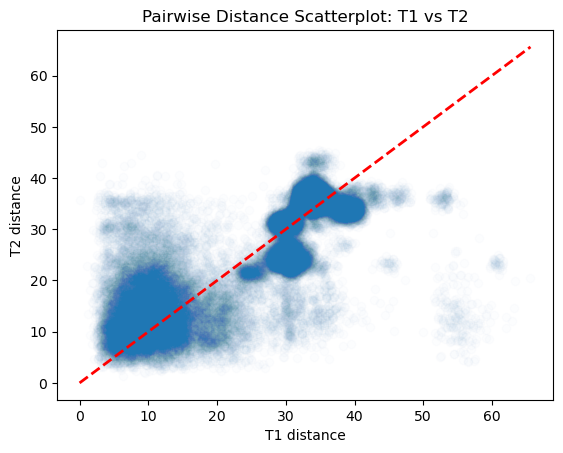

In [194]:
plt.scatter(d_t1[idx], d_t2[idx], alpha=0.01)
# get min and max for axis range
min_val = min(d_t1[idx].min(), d_t2[idx].min())
max_val = max(d_t1[idx].max(), d_t2[idx].max())
# plot 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel("T1 distance")
plt.ylabel("T2 distance")
plt.title("Pairwise Distance Scatterplot: T1 vs T2")
plt.show()

In [195]:
d_t1 = pairwise_distances(t1_data_std)
d_adc = pairwise_distances(adc_data_std)

# get upper triangle indices (excluding diagonal)
idx = np.triu_indices_from(d_t1, k=1)

corr = np.corrcoef(d_t1[idx], d_adc[idx])[0, 1]
print("Distance correlation:", corr)

Distance correlation: 0.7974189802067101


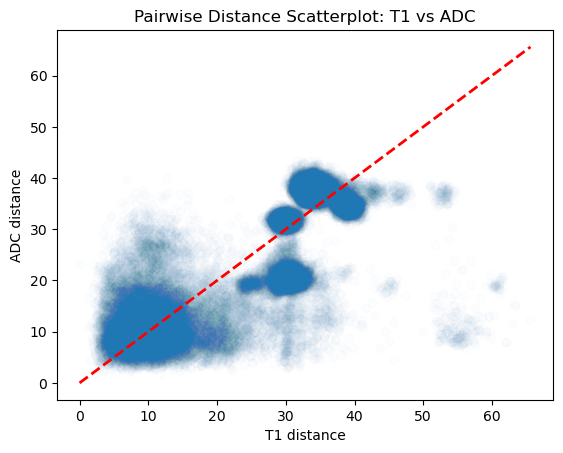

In [196]:
plt.scatter(d_t1[idx], d_adc[idx], alpha=0.01)
# get min and max for axis range
min_val = min(d_t1[idx].min(), d_adc[idx].min())
max_val = max(d_t1[idx].max(), d_adc[idx].max())

# plot 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel("T1 distance")
plt.ylabel("ADC distance")
plt.title("Pairwise Distance Scatterplot: T1 vs ADC")
plt.show()

In [197]:
d_t2 = pairwise_distances(t2_data_std)
d_adc = pairwise_distances(adc_data_std)

# get upper triangle indices (excluding diagonal)
idx = np.triu_indices_from(d_t2, k=1)

corr = np.corrcoef(d_t2[idx], d_adc[idx])[0, 1]
print("Distance correlation:", corr)

Distance correlation: 0.9010243689028876


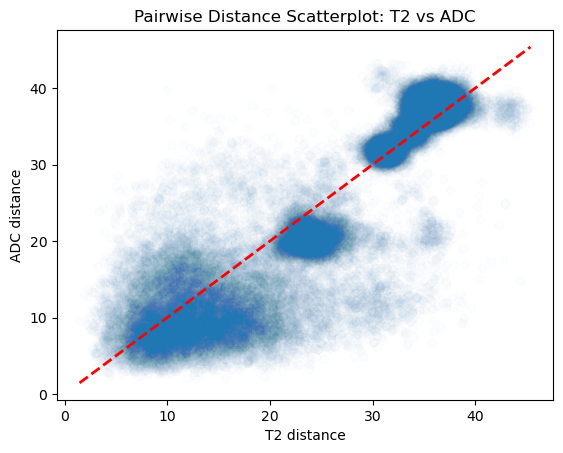

In [198]:

plt.scatter(d_t2[idx], d_adc[idx], alpha=0.01)
# get min and max for axis range
min_val = min(d_t2[idx].min(), d_adc[idx].min())
max_val = max(d_t2[idx].max(), d_adc[idx].max())
# plot 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel("T2 distance")
plt.ylabel("ADC distance")
plt.title("Pairwise Distance Scatterplot: T2 vs ADC")
plt.show()

To assess the overall geometric consistency across modalities, we computed the pairwise distance matrices for T1, T2, and ADC features and evaluated their correlations. The results show relatively high agreement (T1–T2 ≈ 0.79, T1–ADC ≈ 0.80, T2–ADC ≈ 0.90), indicating that the three modalities share a largely consistent global structure in the feature space. In other words, patient-level similarities are broadly preserved across modalities, suggesting that they capture common underlying characteristics of the data distribution. However, such global agreement does not preclude the existence of finer, modality-specific variations that may be critical for distinguishing LVSI status. Therefore, to further investigate whether complementary local patterns exist, we next examine low-dimensional embeddings using t-SNE to explore neighborhood-level structure and potential modality-specific clustering behavior.

## Local Motality -- 2D/3D T-SNE

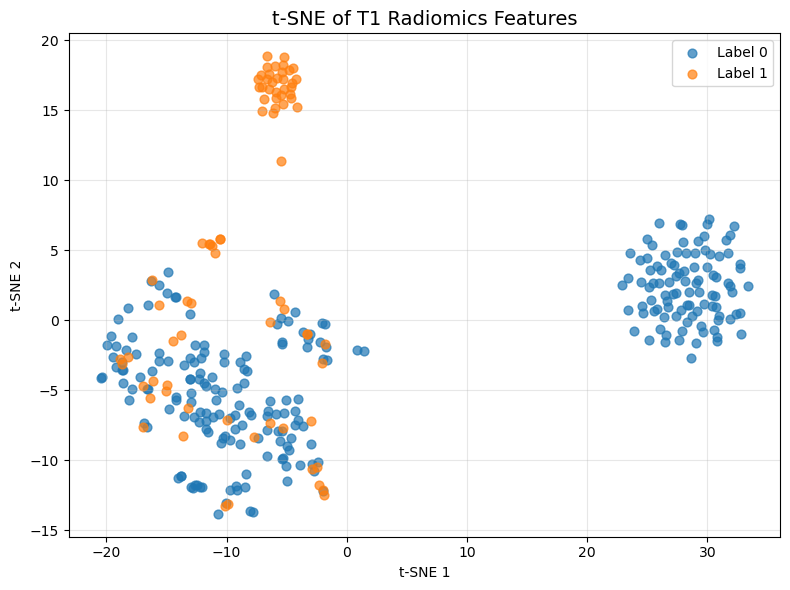

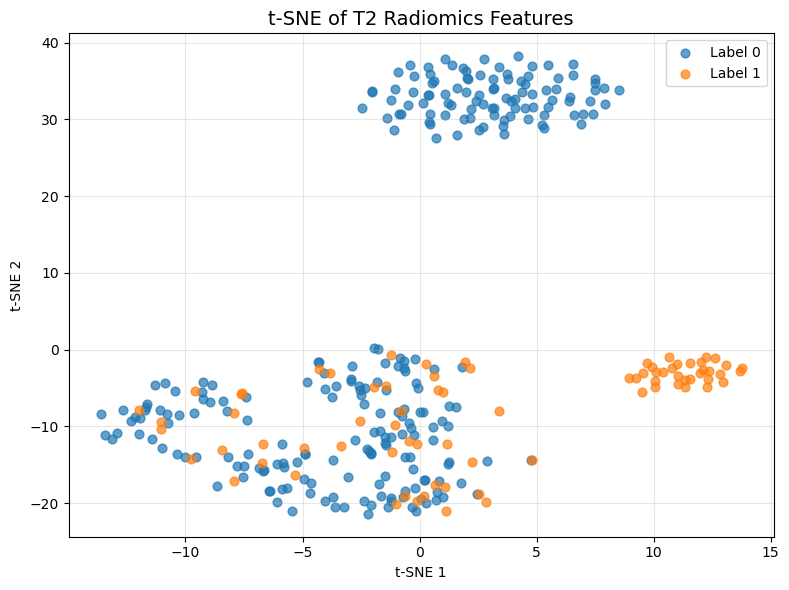

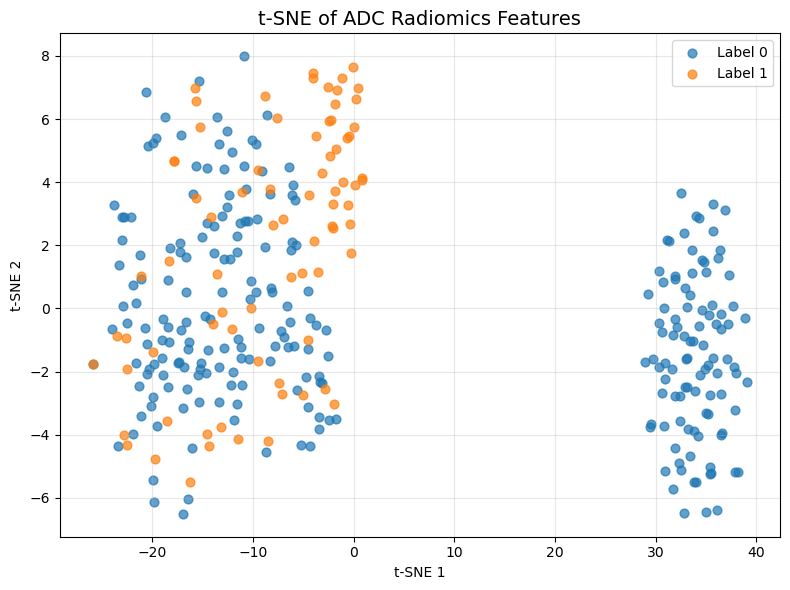

In [199]:
# 2D T-SNE and plotting
from sklearn.manifold import TSNE

t1_label = np.asarray(t1_label).ravel()
t2_label = np.asarray(t2_label).ravel()
adc_label = np.asarray(adc_label).ravel()

def run_tsne_and_plot(X, y, title, perplexity=30, random_state=42):
    """
    Run t-SNE on one dataset and make a scatter plot.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Standardized feature matrix.
    y : array-like of shape (n_samples,)
        Labels.
    title : str
        Plot title.
    perplexity : int, default=30
        t-SNE perplexity. Should usually be < n_samples.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    X_tsne : ndarray of shape (n_samples, 2)
        2D t-SNE embedding.
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        max_iter=1000
    )

    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(y)

    for label in unique_labels:
        idx = (y == label)
        plt.scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=f"Label {label}",
            alpha=0.7,
            s=40
        )

    plt.title(title, fontsize=14)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return X_tsne

# Run t-SNE on each standardized dataset
t1_tsne = run_tsne_and_plot(t1_data_std, t1_label, "t-SNE of T1 Radiomics Features")
t2_tsne = run_tsne_and_plot(t2_data_std, t2_label, "t-SNE of T2 Radiomics Features")
adc_tsne = run_tsne_and_plot(adc_data_std, adc_label, "t-SNE of ADC Radiomics Features")

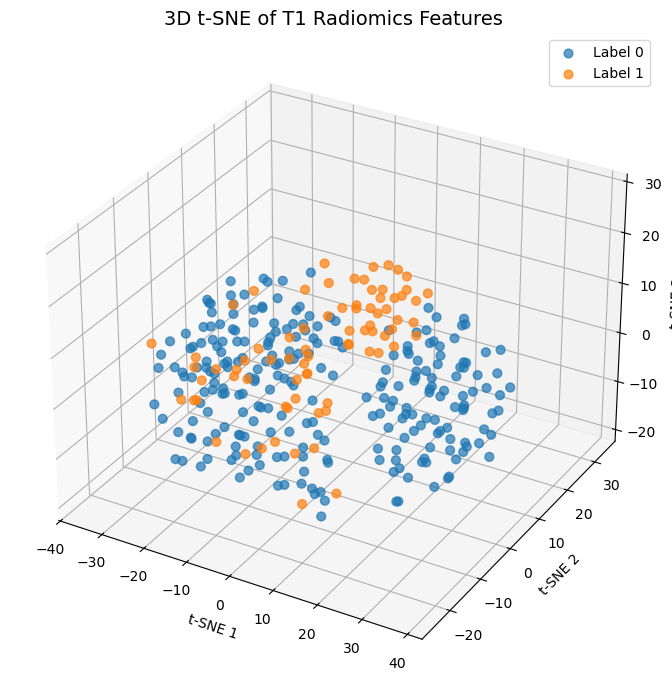

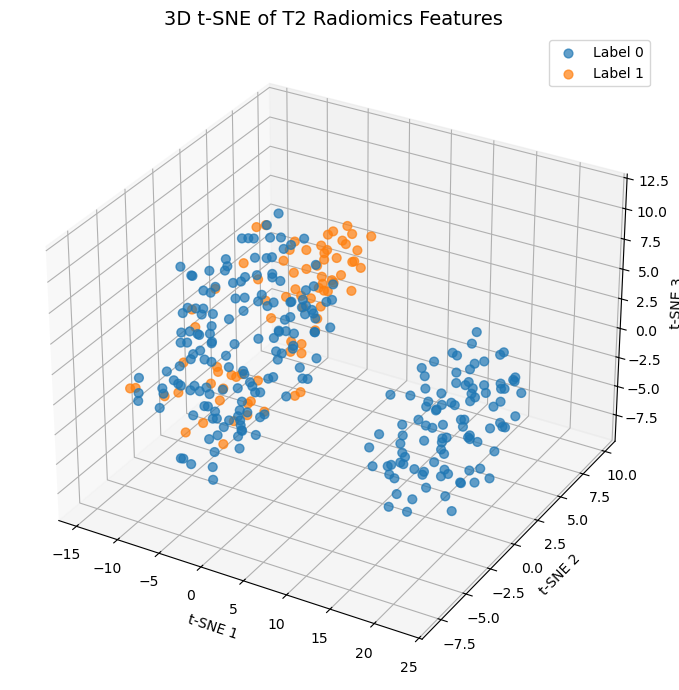

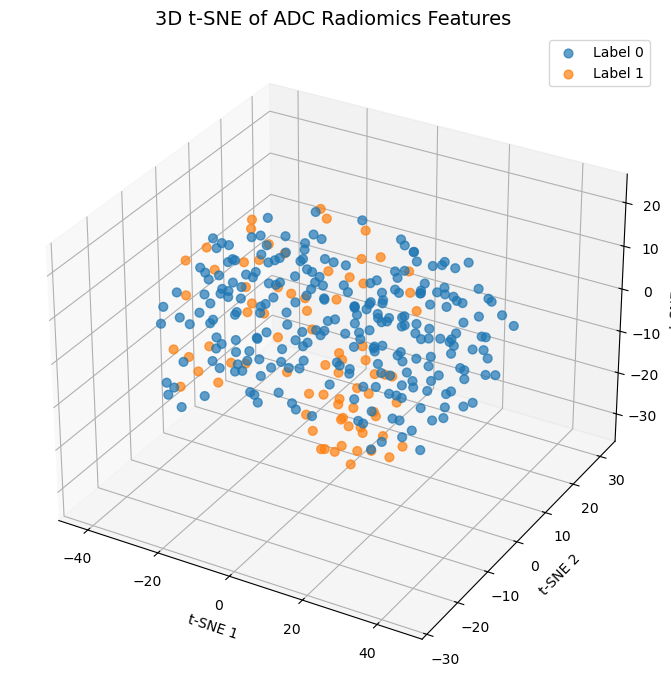

In [200]:
# 3D T-SNE and plotting
from mpl_toolkits.mplot3d import Axes3D  

def run_tsne_3d_and_plot(X, y, title, perplexity=30, random_state=42):
    """
    Run 3D t-SNE on one dataset and make a 3D scatter plot.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Standardized feature matrix.
    y : array-like of shape (n_samples,)
        Labels.
    title : str
        Plot title.
    perplexity : int, default=30
        t-SNE perplexity.
    random_state : int, default=42
        Random seed.

    Returns
    -------
    X_tsne : ndarray of shape (n_samples, 3)
        3D t-SNE embedding.
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    tsne = TSNE(
        n_components=3,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        max_iter=1000
    )

    X_tsne = tsne.fit_transform(X)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    unique_labels = np.unique(y)

    for label in unique_labels:
        idx = (y == label)
        ax.scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            X_tsne[idx, 2],
            label=f"Label {label}",
            alpha=0.7,
            s=40
        )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_zlabel("t-SNE 3")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return X_tsne

# Run on each dataset
t1_tsne_3d = run_tsne_3d_and_plot(t1_data_std, t1_label, "3D t-SNE of T1 Radiomics Features")
t2_tsne_3d = run_tsne_3d_and_plot(t2_data_std, t2_label, "3D t-SNE of T2 Radiomics Features")
adc_tsne_3d = run_tsne_3d_and_plot(adc_data_std, adc_label, "3D t-SNE of ADC Radiomics Features")

T1, T2 show similar local patterns, which means they can partially separate a subset of Label 0 and a subset of Label 1; while ADC can only separate a subset of Label 0 very well. These further implies the underlying structure is heterogeneous, LVSI is not one uniform pattern that different patients show different imaging signatures. These t-SNE visualizations reveal that T1, T2, and ADC may encode complementary but incomplete representations of LVSI, indicating that no single modality is sufficient and motivating multi-modal fusion in our later analysis and model construction.